# Unit 6 — Data Viz and Data Storytelling

**Course:** Data Science (Optativa I) — FURB 2026  
**Lecture reference:** Lecture 14 — Data Viz and Data Storytelling  
**Dataset:** OECD GDP per Capita × Unemployment Rate — Extended 2023–2025  
**Dataset (cross-section):** OECD 2025 quarterly snapshot (38 countries)

This notebook applies Lecture 14 principles to **communicate** the findings from all previous units.
It does not generate new analytical results — it transforms the existing evidence into:
- Polished **explanatory visualizations** (vs the exploratory charts from earlier units)
- A structured **data story**: problem → analysis → conclusion
- A summary **dashboard** consolidating the key findings

> *"Before designing the visuals, write the story. This helps clarify the message, organize the logic,*  
> *and identify which visualizations are necessary."* — Lecture 14

---
## 1. Setup and Data Loading

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# ── Consistent color palette (Lecture 14: use color with a clear function) ────
CLUSTER_COLORS = ["#2166AC", "#D6604D", "#1B7837", "#762A83"]
C_GDP   = "#2166AC"
C_UNE   = "#D6604D"
C_GRAY  = "#AAAAAA"
C_HIGHLIGHT = "#F4A582"
C_OUTLIER   = "#B2182B"

# ── Data loading ──────────────────────────────────────────────────────────────
df_ext  = pd.read_csv("datasets/extended/gdp_unemployment_featured.csv", sep=";")
df_2025 = pd.read_csv("datasets/gdp_unemployment_merged.csv", sep=";")

# Annual country means (2025 cross-section) — one row per country
annual = (
    df_2025
    .groupby("REF_AREA", as_index=False)[["GDP_PER_CAPITA_USD_PPP", "UNE_RATE_PCT"]]
    .mean()
    .sort_values("GDP_PER_CAPITA_USD_PPP", ascending=False)
    .reset_index(drop=True)
)

print(f"Extended dataset : {df_ext.shape[0]:>4} rows × {df_ext.shape[1]} columns  (2023–2025)")
print(f"2025 quarterly   : {df_2025.shape[0]:>4} rows | {df_2025['REF_AREA'].nunique()} countries")
print(f"Annual 2025 means: {len(annual):>4} countries (one row each)")

Extended dataset :  453 rows × 22 columns  (2023–2025)
2025 quarterly   :  146 rows | 38 countries
Annual 2025 means:   38 countries (one row each)


---
## 2. The Data Story — Writing the Narrative First

Lecture 14: *"Data storytelling is a form of writing: a structured narrative that uses evidence to make an argument."*  
Before drawing any chart, we establish the story structure:

| Story beat | Content |
|---|---|
| **Problem and context** | Do richer countries (higher GDP per capita) have lower unemployment? This is the core prediction of Okun's Law, one of the oldest ideas in macroeconomics. |
| **Data** | OECD quarterly data for 38 countries, 2023–2025 (453 observations). Two variables: GDP per capita (USD PPP, constant 2020 prices) and unemployment rate (%, age 15+). |
| **First analysis (2025 snapshot)** | Looking at only 2025, the pattern is weakly negative (Pearson r = −0.11) but statistically non-significant (p = 0.49). One year of data is not enough. |
| **Extended analysis (2023–2025)** | Adding 2023–2024 data and computing year-over-year changes, the signal becomes detectable: r = −0.24, p < 0.0001. Okun's Law is visible — but only in the *changes*, not the *levels*. |
| **Clustering** | k-Means (k = 4) reveals four distinct country profiles: high-wealth stable, high-wealth dynamic, emerging fast-growing, and structurally challenged. |
| **Conclusion** | The GDP–unemployment link is real but weak. Country structure (labour institutions, industry mix, social protection) creates massive exceptions that GDP alone cannot explain. |

---
## 3. Visualization Taxonomy (Lecture 14)

Lecture 14 defines two classification axes for visualizations:

| Axis | Option A | Option B |
|---|---|---|
| **Purpose** | **Exploratory** — discover patterns internally | **Explanatory** — communicate findings to audience |
| **Content** | **Conceptual** — ideas, frameworks, relationships | **Data-driven** — measures, distributions, patterns |

**How this maps to our project:**

| Chart | Type | Notes |
|---|---|---|
| unit2: bar charts, raw distributions | Exploratory + Data-driven | Draft output for internal EDA |
| unit3: histograms, boxplots, correlation scatter | Exploratory + Data-driven | Internal EDA, no polished labels |
| **This notebook — all charts** | **Explanatory + Data-driven** | Polished titles, labeled outliers, context, source |

> The same data can produce exploratory or explanatory visualizations.  
> The difference is **intent**: are you discovering, or are you communicating?

---
## 4. Distribution Visualizations — Small Multiples

**Lecture 14 principle — Small Multiples:**  
*"Use the same axes and scales whenever possible. Repetition helps the reader focus on the data rather than on how the chart works."*

We place the GDP and unemployment distributions side by side using the same visual structure.
The contrast in skewness and spread is immediately visible without any text explanation.

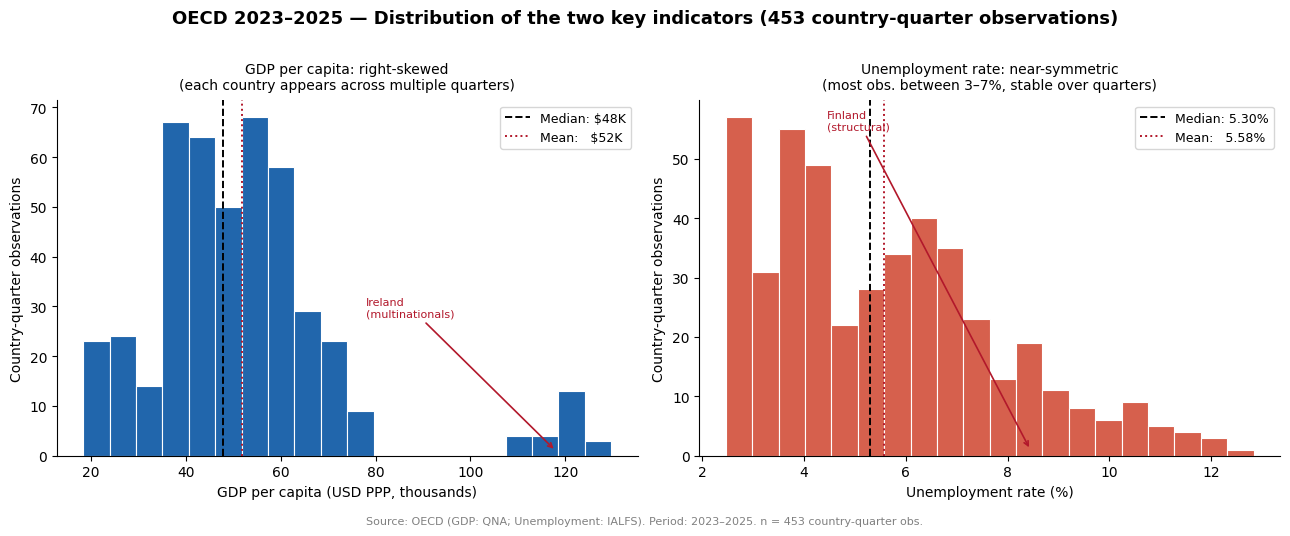

Fig 1 saved: unit6_fig1_distributions.png


In [13]:

# ── Use full panel dataset for distributions (all 453 country-quarter obs) ────
df_dist = df_ext[["REF_AREA", "GDP_PER_CAPITA_USD_PPP", "UNE_RATE_PCT"]].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "OECD 2023–2025 — Distribution of the two key indicators (453 country-quarter observations)",
    fontsize=13, fontweight="bold", y=1.01
)

# ── Left: GDP per capita ──────────────────────────────────────────────────────
ax = axes[0]
ax.hist(df_dist["GDP_PER_CAPITA_USD_PPP"] / 1000, bins=20, color=C_GDP, edgecolor="white", linewidth=0.8)
gdp_median = df_dist["GDP_PER_CAPITA_USD_PPP"].median() / 1000
gdp_mean   = df_dist["GDP_PER_CAPITA_USD_PPP"].mean()   / 1000
ax.axvline(gdp_median, color="black",   linestyle="--", linewidth=1.4, label=f"Median: ${gdp_median:.0f}K")
ax.axvline(gdp_mean,   color=C_OUTLIER, linestyle=":",  linewidth=1.4, label=f"Mean:   ${gdp_mean:.0f}K")
irl_gdp = df_dist.loc[df_dist["REF_AREA"] == "IRL", "GDP_PER_CAPITA_USD_PPP"].mean() / 1000
ax.annotate(
    "Ireland\n(multinationals)",
    xy=(irl_gdp, 1), xytext=(irl_gdp - 40, 28),
    fontsize=8, color=C_OUTLIER,
    arrowprops=dict(arrowstyle="->", color=C_OUTLIER, lw=1.2),
)
ax.set_xlabel("GDP per capita (USD PPP, thousands)", fontsize=10)
ax.set_ylabel("Country-quarter observations", fontsize=10)
ax.set_title("GDP per capita: right-skewed\n(each country appears across multiple quarters)", fontsize=10, pad=8)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# ── Right: Unemployment rate ──────────────────────────────────────────────────
ax = axes[1]
ax.hist(df_dist["UNE_RATE_PCT"], bins=20, color=C_UNE, edgecolor="white", linewidth=0.8)
une_median = df_dist["UNE_RATE_PCT"].median()
une_mean   = df_dist["UNE_RATE_PCT"].mean()
ax.axvline(une_median, color="black",   linestyle="--", linewidth=1.4, label=f"Median: {une_median:.2f}%")
ax.axvline(une_mean,   color=C_OUTLIER, linestyle=":",  linewidth=1.4, label=f"Mean:   {une_mean:.2f}%")
fin_une = df_dist.loc[df_dist["REF_AREA"] == "FIN", "UNE_RATE_PCT"].mean()
ax.annotate(
    "Finland\n(structural)",
    xy=(fin_une, 1), xytext=(fin_une - 4, 55),
    fontsize=8, color=C_OUTLIER,
    arrowprops=dict(arrowstyle="->", color=C_OUTLIER, lw=1.2),
)
ax.set_xlabel("Unemployment rate (%)", fontsize=10)
ax.set_ylabel("Country-quarter observations", fontsize=10)
ax.set_title("Unemployment rate: near-symmetric\n(most obs. between 3–7%, stable over quarters)", fontsize=10, pad=8)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.02,
         f"Source: OECD (GDP: QNA; Unemployment: IALFS). Period: 2023–2025. n = {len(df_dist)} country-quarter obs.",
         ha="center", fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("unit6_fig1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 1 saved: unit6_fig1_distributions.png")


---
## 5. The Central Finding — GDP × Unemployment (All 453 Observations)

**Lecture 14 — Preattentive visual attributes:**  
*"Use color, shapes, size, position, or contrast to guide attention and highlight the main analytical message."*

This chart uses the **full panel dataset** (453 country-quarter observations, 2023–2025), not annual country averages.  
Each country appears up to 12 times — once per quarter. This is intentional: it shows the data as it actually is, with recurrence.

Visual encoding choices:
- **Grey dots** = all 453 observations (background, full picture)
- **Colored trajectory lines** = 6 story-relevant countries across all their quarters — shows how each country moves over time in this 2D space
- **Dashed trend line** = OLS fit to all 453 observations
- **Dotted grey lines** = median GDP and median unemployment (panel medians), splitting into four quadrants

**Reading the quadrants:**

| Quadrant | GDP | UNE | Countries (examples) | Theory |
|---|---|---|---|---|
| Top-right | High | High | Finland, France, Belgium | **Theory breaks** |
| Bottom-right | High | Low | USA, Norway, Germany, Korea | **Theory holds** |
| Bottom-left | Low | Low | Japan, Mexico, Czech Republic | **Reversed expectation** |
| Top-left | Low | High | Greece, Spain, Chile | Theory holds in this direction |


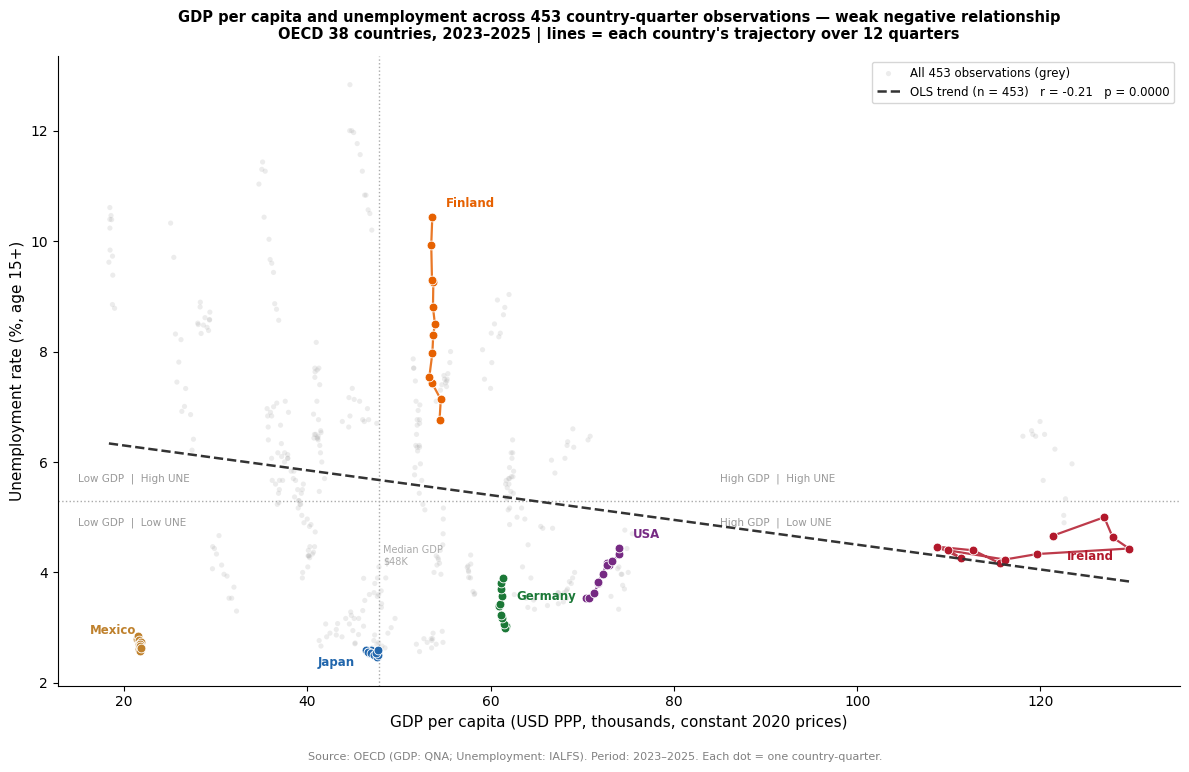

Fig 2 saved: unit6_fig2_scatter_panel.png
  Pearson r = -0.2058   p = 0.0000   n = 453


In [14]:

# ── Full panel dataset (453 country-quarter observations, 2023–2025) ──────────
df_panel = (
    df_ext[["REF_AREA", "QUARTER", "GDP_PER_CAPITA_USD_PPP", "UNE_RATE_PCT"]]
    .dropna()
    .sort_values(["REF_AREA", "QUARTER"])
    .reset_index(drop=True)
)

x_panel = df_panel["GDP_PER_CAPITA_USD_PPP"].values
y_panel = df_panel["UNE_RATE_PCT"].values

# OLS on all 453 obs
slope, intercept, r_val, p_val, se = stats.linregress(x_panel, y_panel)
x_line = np.linspace(x_panel.min(), x_panel.max(), 200)
y_line = slope * x_line + intercept

# Median split (full panel)
gdp_med = np.median(x_panel)
une_med = np.median(y_panel)

# Countries to highlight with trajectory lines + labels
TRAJ_COUNTRIES = {
    "IRL": (C_OUTLIER,   "Ireland"),
    "FIN": ("#E66101",   "Finland"),
    "JPN": (C_GDP,       "Japan"),
    "DEU": ("#1B7837",   "Germany"),
    "USA": ("#762A83",   "USA"),
    "MEX": ("#BF812D",   "Mexico"),
}

# ── Countries to label (latest quarter only) ──────────────────────────────────
LABEL_COUNTRIES = {
    "IRL": "Ireland", "FIN": "Finland", "LUX": "Luxembourg",
    "JPN": "Japan",   "MEX": "Mexico",  "USA": "USA",
    "NOR": "Norway",  "GRC": "Greece",  "TUR": "Türkiye",
    "DEU": "Germany", "FRA": "France",  "CHL": "Chile",
    "COL": "Colombia",
}

fig, ax = plt.subplots(figsize=(12, 7.5))

# All observations — grey background
ax.scatter(
    df_panel["GDP_PER_CAPITA_USD_PPP"] / 1000,
    df_panel["UNE_RATE_PCT"],
    color=C_GRAY, s=14, alpha=0.22, edgecolors="none", zorder=2,
    label=f"All {len(df_panel)} observations (grey)"
)

# Trajectory lines per key country
for code, (color, name) in TRAJ_COUNTRIES.items():
    sub = df_panel[df_panel["REF_AREA"] == code]
    if sub.empty:
        continue
    ax.plot(
        sub["GDP_PER_CAPITA_USD_PPP"] / 1000, sub["UNE_RATE_PCT"],
        color=color, linewidth=1.6, alpha=0.85, zorder=3
    )
    ax.scatter(
        sub["GDP_PER_CAPITA_USD_PPP"] / 1000, sub["UNE_RATE_PCT"],
        color=color, s=40, zorder=4, edgecolors="white", linewidth=0.6
    )
    # Label at the latest quarter
    last = sub.sort_values("QUARTER").iloc[-1]
    offset_x = 1.5
    offset_y = 0.18
    if code == "IRL": offset_y = -0.45
    if code == "JPN": offset_x = -6.5; offset_y = -0.30
    if code == "MEX": offset_x = -5.5; offset_y = +0.25
    if code == "DEU": offset_x = 1.5;  offset_y = -0.40
    ax.annotate(
        name,
        xy=(last["GDP_PER_CAPITA_USD_PPP"] / 1000, last["UNE_RATE_PCT"]),
        xytext=(last["GDP_PER_CAPITA_USD_PPP"] / 1000 + offset_x,
                last["UNE_RATE_PCT"] + offset_y),
        fontsize=8.5, color=color, fontweight="bold",
    )

# OLS trend line
ax.plot(
    x_line / 1000, y_line,
    color="#333333", linestyle="--", linewidth=1.8, zorder=5,
    label=f"OLS trend (n = {len(df_panel)})   r = {r_val:.2f}   p = {p_val:.4f}"
)

# Median split lines
ax.axvline(gdp_med / 1000, color=C_GRAY, linestyle=":", linewidth=1.0)
ax.axhline(une_med,        color=C_GRAY, linestyle=":", linewidth=1.0)
ax.text(gdp_med / 1000 + 0.5, une_med - 0.8,
        f"Median GDP\n${gdp_med/1000:.0f}K", fontsize=7, color=C_GRAY, va="top")

# Quadrant labels (bottom corners)
ax.text(15,  une_med + 0.3, "Low GDP  |  High UNE", fontsize=7.5, color="#999999", va="bottom")
ax.text(85,  une_med + 0.3, "High GDP  |  High UNE", fontsize=7.5, color="#999999", va="bottom")
ax.text(15,  une_med - 0.3, "Low GDP  |  Low UNE",  fontsize=7.5, color="#999999", va="top")
ax.text(85,  une_med - 0.3, "High GDP  |  Low UNE", fontsize=7.5, color="#999999", va="top")

ax.set_xlabel("GDP per capita (USD PPP, thousands, constant 2020 prices)", fontsize=11)
ax.set_ylabel("Unemployment rate (%, age 15+)", fontsize=11)
ax.set_title(
    "GDP per capita and unemployment across 453 country-quarter observations — weak negative relationship\n"
    "OECD 38 countries, 2023–2025 | lines = each country's trajectory over 12 quarters",
    fontsize=10.5, fontweight="bold", pad=12
)
ax.legend(fontsize=8.5, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.5, -0.02,
         "Source: OECD (GDP: QNA; Unemployment: IALFS). Period: 2023–2025. Each dot = one country-quarter.",
         ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("unit6_fig2_scatter_panel.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Fig 2 saved: unit6_fig2_scatter_panel.png")
print(f"  Pearson r = {r_val:.4f}   p = {p_val:.4f}   n = {len(df_panel)}")


---
## 6. Why One Year Was Not Enough — Okun's Law in Year-over-Year Changes

The 2025 snapshot gives r = −0.11 (p = 0.49) — not significant.  
But Okun's Law is a **dynamic** relationship: it describes how *changes* in GDP relate to *changes* in unemployment.  

By extending the dataset to 2023–2025 and computing year-over-year (YoY) changes, we get:  
**r = −0.24, p < 0.0001** — statistically significant.

**Lecture 14 — Explanatory vs Exploratory:**  
This chart is **explanatory**: it is designed to answer a specific claim — *"Okun's Law is detectable when we measure change, not level"* — and the visual is structured to make that claim clear.

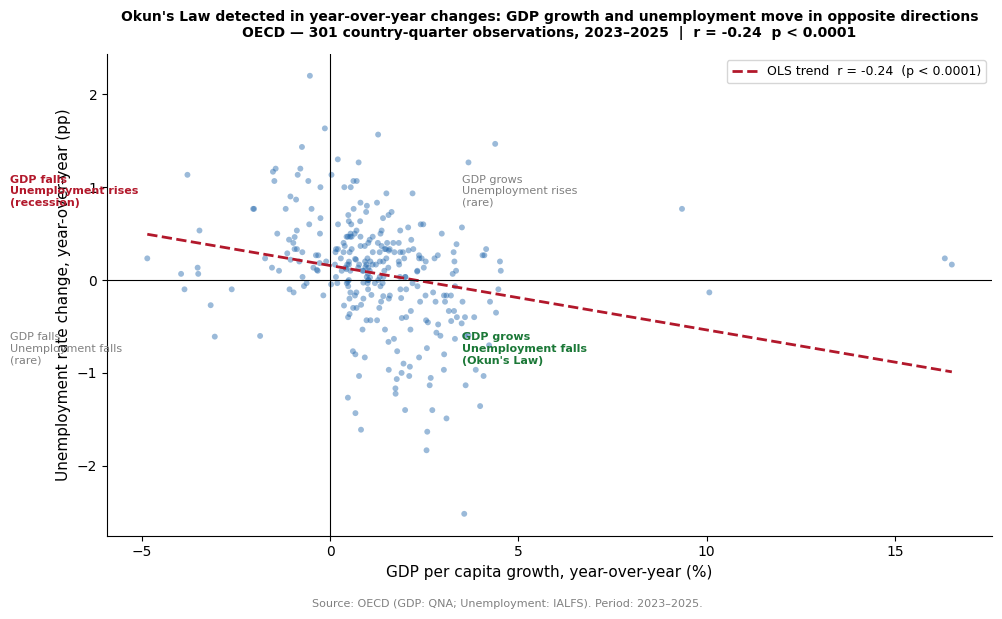

Fig 3 saved. YoY Pearson r = -0.2421  p = 0.000022  n = 301


In [15]:
# ── YoY scatter: GDP growth vs unemployment change ────────────────────────────
df_yoy = df_ext[["REF_AREA", "QUARTER", "GDP_GROWTH_YOY_PCT", "UNE_CHANGE_YOY_PP"]].dropna()

x_yoy = df_yoy["GDP_GROWTH_YOY_PCT"].values
y_yoy = df_yoy["UNE_CHANGE_YOY_PP"].values
r_yoy, p_yoy = pearsonr(x_yoy, y_yoy)

slope_y, intercept_y, *_ = stats.linregress(x_yoy, y_yoy)
x_range = np.linspace(x_yoy.min(), x_yoy.max(), 200)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x_yoy, y_yoy, color=C_GDP, s=18, alpha=0.45, edgecolors="none", zorder=2)
ax.plot(x_range, slope_y * x_range + intercept_y,
        color="#B2182B", linewidth=2.0, linestyle="--",
        label=f"OLS trend  r = {r_yoy:.2f}  (p < 0.0001)")

# Reference lines
ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax.axvline(0, color="black", linewidth=0.8, linestyle="-")

# Quadrant annotations
ax.text( 3.5,  0.8, "GDP grows\nUnemployment rises\n(rare)",  fontsize=8, color="gray", ha="left")
ax.text( 3.5, -0.9, "GDP grows\nUnemployment falls\n(Okun's Law)", fontsize=8, color="#1B7837", ha="left", fontweight="bold")
ax.text(-8.5,  0.8, "GDP falls\nUnemployment rises\n(recession)", fontsize=8, color="#B2182B", ha="left", fontweight="bold")
ax.text(-8.5, -0.9, "GDP falls\nUnemployment falls\n(rare)", fontsize=8, color="gray", ha="left")

ax.set_xlabel("GDP per capita growth, year-over-year (%)", fontsize=11)
ax.set_ylabel("Unemployment rate change, year-over-year (pp)", fontsize=11)
ax.set_title(
    "Okun's Law detected in year-over-year changes: GDP growth and unemployment move in opposite directions\n"
    f"OECD — {len(df_yoy)} country-quarter observations, 2023–2025  |  r = {r_yoy:.2f}  p < 0.0001",
    fontsize=10, fontweight="bold", pad=12
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.5, -0.02, "Source: OECD (GDP: QNA; Unemployment: IALFS). Period: 2023–2025.", ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("unit6_fig3_yoy_okun.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Fig 3 saved. YoY Pearson r = {r_yoy:.4f}  p = {p_yoy:.6f}  n = {len(df_yoy)}")

---
## 7. Country Groups — k-Means Cluster Results

k-Means (k = 4) groups the 453 country-quarter observations by:
- `GDP_PER_CAPITA_USD_PPP` — wealth level  
- `UNE_RATE_PCT` — labour market situation  
- `GDP_GROWTH_YOY_PCT` — economic momentum

We visualise the cluster structure using **PCA** (Principal Component Analysis) to reduce the 3 standardised features to 2 dimensions — making the spatial separation between groups visible.

**Lecture 14 — Visual integrity:**  
*"A chart should not distort magnitudes or relationships between variables."*  
PCA is disclosed explicitly, axes are labelled with their explained variance, and we do not imply the 2D projection is exact.

In [16]:
# ── Re-run k-Means (k=4) to get cluster labels ────────────────────────────────
cluster_features = ["GDP_PER_CAPITA_USD_PPP", "UNE_RATE_PCT", "GDP_GROWTH_YOY_PCT"]
X_raw = df_ext[cluster_features + ["REF_AREA", "QUARTER"]].dropna(subset=cluster_features).copy()
X     = X_raw[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

km = KMeans(n_clusters=4, random_state=42, n_init=20)
X_raw["cluster"] = km.fit_predict(X_scaled)

# Descriptive cluster labels (assigned by inspecting centroids)
centroids_orig = scaler.inverse_transform(km.cluster_centers_)
centroid_df = pd.DataFrame(centroids_orig, columns=cluster_features)
centroid_df.index.name = "cluster"
# Sort by GDP to get stable ordering
centroid_df = centroid_df.sort_values("GDP_PER_CAPITA_USD_PPP")
print("Cluster centroids (original scale):")
print(centroid_df.round(2))
print()
print("Cluster sizes:")
print(X_raw["cluster"].value_counts().sort_index())

Cluster centroids (original scale):
         GDP_PER_CAPITA_USD_PPP  UNE_RATE_PCT  GDP_GROWTH_YOY_PCT
cluster                                                          
2                      41757.71          3.72                1.85
0                      43290.70          7.90                1.49
1                      70669.73          4.67               -0.07
3                     126035.32          4.60               13.07

Cluster sizes:
cluster
0    115
1     91
2     91
3      4
Name: count, dtype: int64


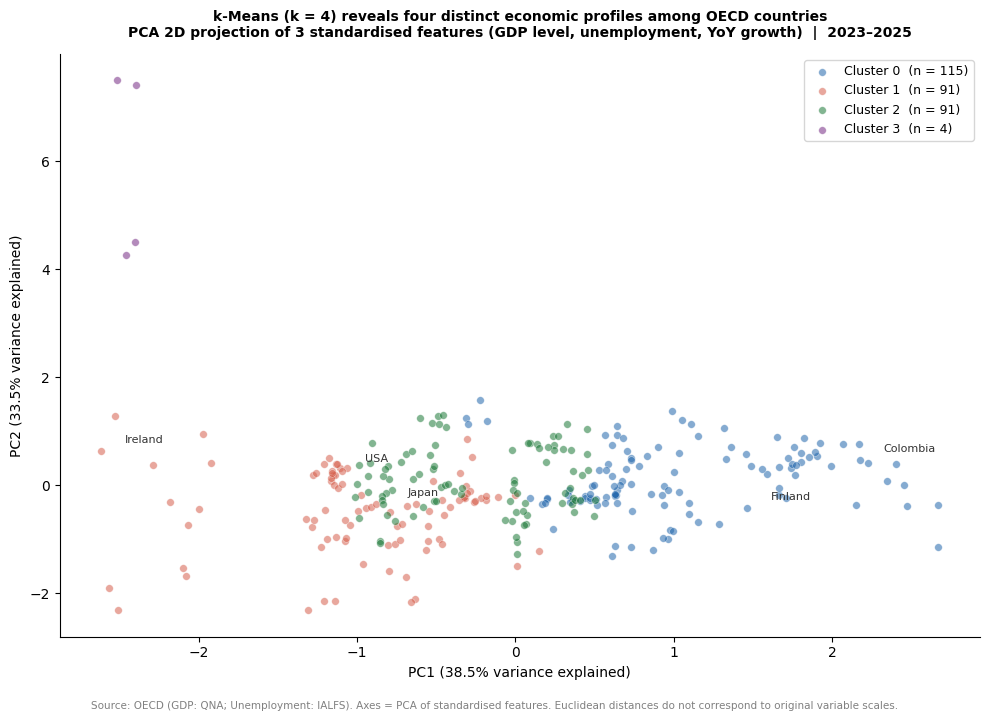

Fig 4 saved. Total variance explained by 2 PCs: 72.0%


In [17]:
# ── PCA 2D projection ─────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))

for c_id, color in enumerate(CLUSTER_COLORS):
    mask = X_raw["cluster"] == c_id
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        color=color, s=30, alpha=0.55, edgecolors="white", linewidth=0.4,
        label=f"Cluster {c_id}  (n = {mask.sum()})"
    )

# Label a few representative countries in the PCA space
country_labels = {"IRL": "Ireland", "FIN": "Finland", "JPN": "Japan",
                  "USA": "USA", "COL": "Colombia", "TUR": "Türkiye"}
# Use latest quarter per country for labelling
latest = X_raw.sort_values("QUARTER").groupby("REF_AREA").tail(1).reset_index(drop=True)
for idx, row in latest.iterrows():
    if row["REF_AREA"] in country_labels:
        # find position in X_raw
        pos_idx = X_raw.index.get_loc(row.name) if row.name in X_raw.index else None
        # safer: locate by row value match
        match = X_raw[
            (X_raw["REF_AREA"] == row["REF_AREA"]) &
            (X_raw["QUARTER"]  == row["QUARTER"])
        ].index
        if len(match):
            i = X_raw.index.get_loc(match[0])
            ax.annotate(
                country_labels[row["REF_AREA"]],
                xy=(coords[i, 0], coords[i, 1]),
                xytext=(coords[i, 0] + 0.15, coords[i, 1] + 0.15),
                fontsize=8, color="#333333",
            )

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance explained)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance explained)", fontsize=10)
ax.set_title(
    "k-Means (k = 4) reveals four distinct economic profiles among OECD countries\n"
    "PCA 2D projection of 3 standardised features (GDP level, unemployment, YoY growth)  |  2023–2025",
    fontsize=10, fontweight="bold", pad=12
)
ax.legend(fontsize=9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.5, -0.02,
         "Source: OECD (GDP: QNA; Unemployment: IALFS). Axes = PCA of standardised features. "
         "Euclidean distances do not correspond to original variable scales.",
         ha="center", fontsize=7.5, color="gray")

plt.tight_layout()
plt.savefig("unit6_fig4_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Fig 4 saved. Total variance explained by 2 PCs: {sum(var_exp)*100:.1f}%")

---
## 8. Small Multiples — GDP × Unemployment by Cluster

**Lecture 14 — Small multiples:**  
*"Best suited for macro-level and comparative analysis. Repetition helps the reader focus on the data rather than on how the chart works."*

Four panels, one per cluster. Same axes. Same visual structure.  
The reader can immediately compare: which cluster sits where in GDP–unemployment space?

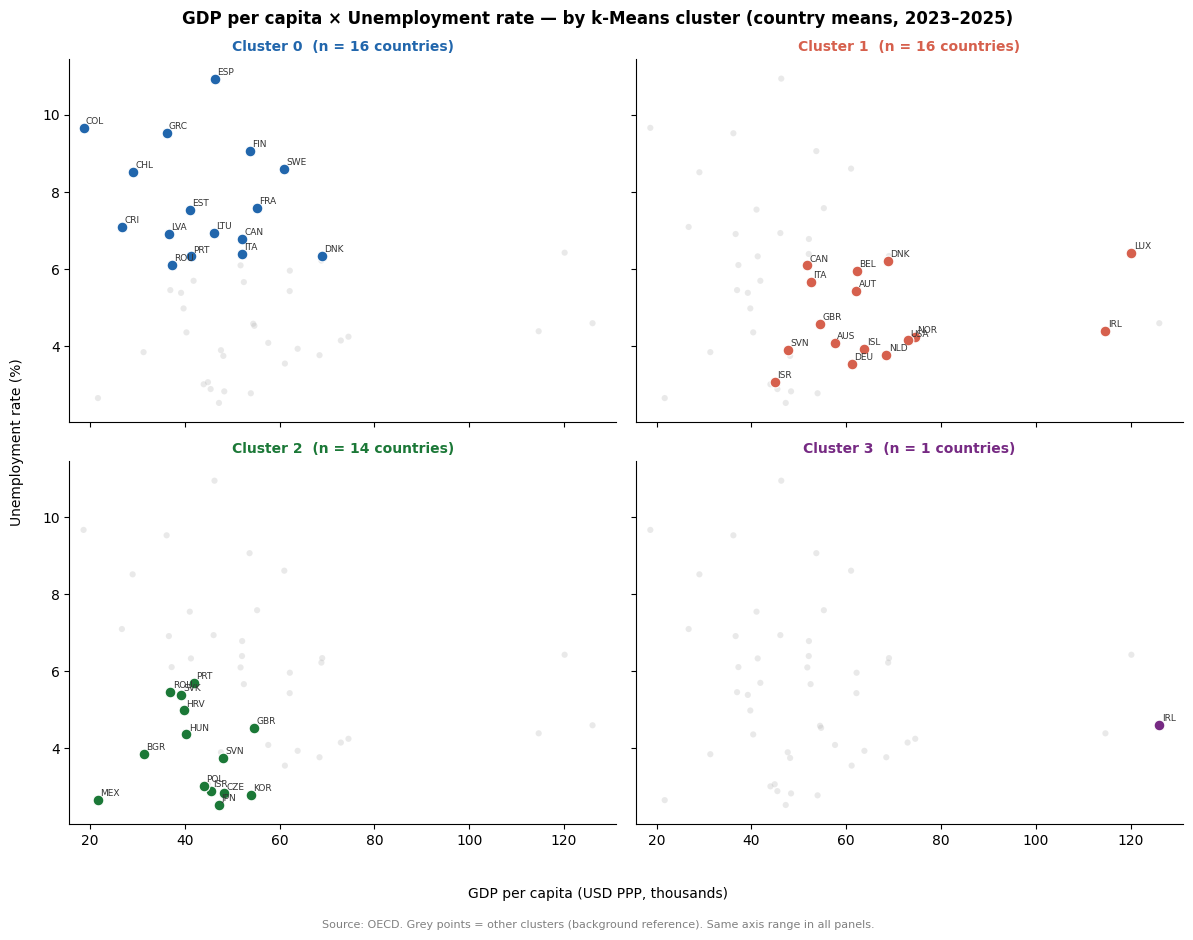

Fig 5 saved: unit6_fig5_small_multiples_clusters.png


In [18]:
# ── Aggregate to country means per cluster ────────────────────────────────────
country_means = (
    X_raw.groupby(["REF_AREA", "cluster"], as_index=False)
    [["GDP_PER_CAPITA_USD_PPP", "UNE_RATE_PCT"]]
    .mean()
)

# Shared axis limits
gdp_min = country_means["GDP_PER_CAPITA_USD_PPP"].min() / 1000 - 3
gdp_max = country_means["GDP_PER_CAPITA_USD_PPP"].max() / 1000 + 5
une_min = country_means["UNE_RATE_PCT"].min() - 0.5
une_max = country_means["UNE_RATE_PCT"].max() + 0.5

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
fig.suptitle(
    "GDP per capita × Unemployment rate — by k-Means cluster (country means, 2023–2025)",
    fontsize=12, fontweight="bold"
)

cluster_titles = [
    "Cluster 0", "Cluster 1",
    "Cluster 2", "Cluster 3",
]

for c_id, ax in enumerate(axes.flat):
    subset = country_means[country_means["cluster"] == c_id]
    ax.scatter(
        subset["GDP_PER_CAPITA_USD_PPP"] / 1000,
        subset["UNE_RATE_PCT"],
        color=CLUSTER_COLORS[c_id], s=60, edgecolors="white", linewidth=0.8, zorder=3
    )
    # All other clusters in grey (background)
    bg = country_means[country_means["cluster"] != c_id]
    ax.scatter(
        bg["GDP_PER_CAPITA_USD_PPP"] / 1000,
        bg["UNE_RATE_PCT"],
        color=C_GRAY, s=20, alpha=0.25, edgecolors="none", zorder=2
    )
    # Label countries
    for _, row in subset.iterrows():
        ax.text(
            row["GDP_PER_CAPITA_USD_PPP"] / 1000 + 0.5,
            row["UNE_RATE_PCT"] + 0.1,
            row["REF_AREA"], fontsize=6.5, color="#333333"
        )
    ax.set_title(f"{cluster_titles[c_id]}  (n = {len(subset)} countries)",
                 fontsize=10, color=CLUSTER_COLORS[c_id], fontweight="bold")
    ax.set_xlim(gdp_min, gdp_max)
    ax.set_ylim(une_min, une_max)
    ax.spines[["top", "right"]].set_visible(False)

# Shared axis labels
fig.supxlabel("GDP per capita (USD PPP, thousands)", fontsize=10, y=-0.01)
fig.supylabel("Unemployment rate (%)", fontsize=10, x=0.01)
fig.text(0.5, -0.04, "Source: OECD. Grey points = other clusters (background reference). Same axis range in all panels.",
         ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("unit6_fig5_small_multiples_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 5 saved: unit6_fig5_small_multiples_clusters.png")

---
## 9. Summary Dashboard — All Key Findings in One Panel

**Lecture 14 — Dashboard:**  
*"A centralized visual panel that presents key information, indicators, and metrics. Used to monitor processes, track performance, compare trends, and support decision-making."*

This 2×2 dashboard combines the four most informative visualizations:

| Panel | What it shows |
|---|---|
| Top-left | GDP distribution — right-skewed, Ireland outlier |
| Top-right | Main cross-section scatter (2025) — weak correlation |
| Bottom-left | YoY dynamics scatter — Okun's Law detected |
| Bottom-right | Cluster PCA projection — 4 distinct country profiles |

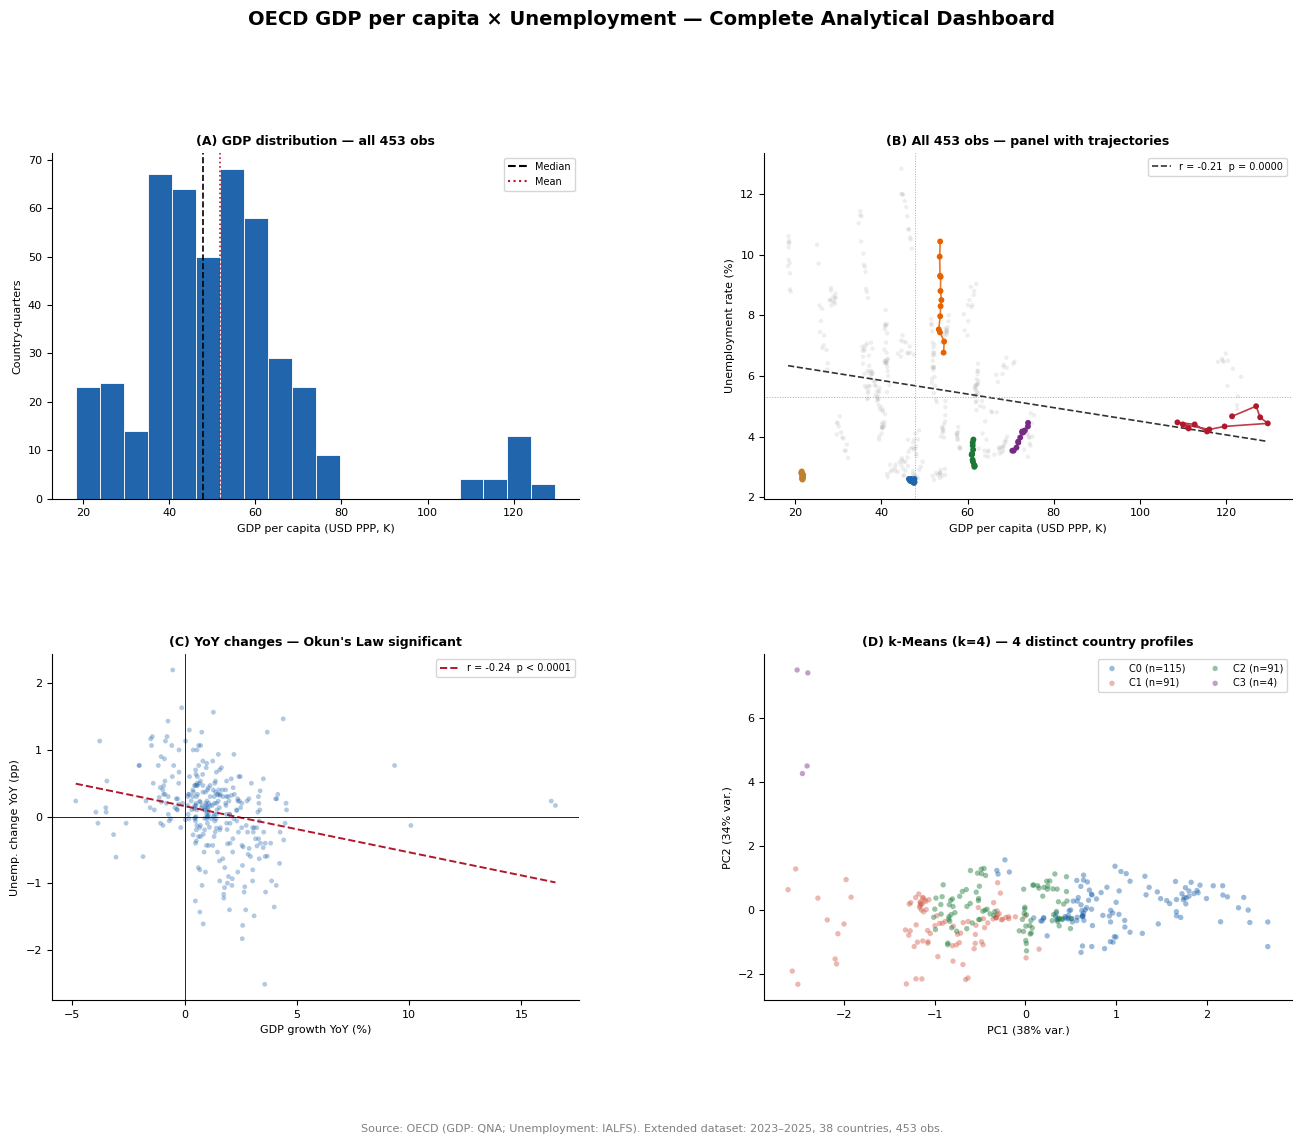

Dashboard saved: unit6_fig6_dashboard.png


In [19]:

fig = plt.figure(figsize=(16, 11))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_tl = fig.add_subplot(gs[0, 0])   # Top-left:    GDP distribution
ax_tr = fig.add_subplot(gs[0, 1])   # Top-right:   panel scatter (all obs)
ax_bl = fig.add_subplot(gs[1, 0])   # Bottom-left: YoY Okun scatter
ax_br = fig.add_subplot(gs[1, 1])   # Bottom-right: cluster PCA

# ── (A) GDP distribution (all 453 obs) ───────────────────────────────────────
ax_tl.hist(df_panel["GDP_PER_CAPITA_USD_PPP"] / 1000, bins=20,
           color=C_GDP, edgecolor="white", linewidth=0.6)
ax_tl.axvline(df_panel["GDP_PER_CAPITA_USD_PPP"].median() / 1000,
              color="black", linestyle="--", linewidth=1.2)
ax_tl.axvline(df_panel["GDP_PER_CAPITA_USD_PPP"].mean() / 1000,
              color=C_OUTLIER, linestyle=":", linewidth=1.2)
ax_tl.set_title("(A) GDP distribution — all 453 obs", fontsize=9, fontweight="bold")
ax_tl.set_xlabel("GDP per capita (USD PPP, K)", fontsize=8)
ax_tl.set_ylabel("Country-quarters", fontsize=8)
ax_tl.tick_params(labelsize=8)
ax_tl.spines[["top", "right"]].set_visible(False)
m1 = mlines.Line2D([], [], color="black",   linestyle="--", label="Median")
m2 = mlines.Line2D([], [], color=C_OUTLIER, linestyle=":",  label="Mean")
ax_tl.legend(handles=[m1, m2], fontsize=7)

# ── (B) Panel scatter — all 453 observations ─────────────────────────────────
ax_tr.scatter(
    df_panel["GDP_PER_CAPITA_USD_PPP"] / 1000, df_panel["UNE_RATE_PCT"],
    color=C_GRAY, s=10, alpha=0.20, edgecolors="none"
)
# Trajectory lines for key countries
for code, (color, name) in TRAJ_COUNTRIES.items():
    sub = df_panel[df_panel["REF_AREA"] == code]
    if sub.empty: continue
    ax_tr.plot(sub["GDP_PER_CAPITA_USD_PPP"] / 1000, sub["UNE_RATE_PCT"],
               color=color, linewidth=1.2, alpha=0.85)
    ax_tr.scatter(sub["GDP_PER_CAPITA_USD_PPP"] / 1000, sub["UNE_RATE_PCT"],
                  color=color, s=18, zorder=4, edgecolors="none")
ax_tr.plot(x_line / 1000, y_line, color="#333333", linestyle="--", linewidth=1.2,
           label=f"r = {r_val:.2f}  p = {p_val:.4f}")
ax_tr.axvline(gdp_med / 1000, color=C_GRAY, linestyle=":", linewidth=0.7)
ax_tr.axhline(une_med,        color=C_GRAY, linestyle=":", linewidth=0.7)
ax_tr.set_title(f"(B) All 453 obs — panel with trajectories", fontsize=9, fontweight="bold")
ax_tr.set_xlabel("GDP per capita (USD PPP, K)", fontsize=8)
ax_tr.set_ylabel("Unemployment rate (%)", fontsize=8)
ax_tr.tick_params(labelsize=8)
ax_tr.legend(fontsize=7)
ax_tr.spines[["top", "right"]].set_visible(False)

# ── (C) YoY Okun scatter ──────────────────────────────────────────────────────
ax_bl.scatter(x_yoy, y_yoy, color=C_GDP, s=12, alpha=0.35, edgecolors="none")
ax_bl.plot(x_range, slope_y * x_range + intercept_y,
           color="#B2182B", linestyle="--", linewidth=1.4,
           label=f"r = {r_yoy:.2f}  p < 0.0001")
ax_bl.axhline(0, color="black", linewidth=0.6)
ax_bl.axvline(0, color="black", linewidth=0.6)
ax_bl.set_title("(C) YoY changes — Okun's Law significant", fontsize=9, fontweight="bold")
ax_bl.set_xlabel("GDP growth YoY (%)", fontsize=8)
ax_bl.set_ylabel("Unemp. change YoY (pp)", fontsize=8)
ax_bl.tick_params(labelsize=8)
ax_bl.legend(fontsize=7)
ax_bl.spines[["top", "right"]].set_visible(False)

# ── (D) Cluster PCA projection ────────────────────────────────────────────────
for c_id, color in enumerate(CLUSTER_COLORS):
    mask = X_raw["cluster"] == c_id
    ax_br.scatter(coords[mask, 0], coords[mask, 1],
                  color=color, s=15, alpha=0.45, edgecolors="none",
                  label=f"C{c_id} (n={mask.sum()})")
ax_br.set_title("(D) k-Means (k=4) — 4 distinct country profiles", fontsize=9, fontweight="bold")
ax_br.set_xlabel(f"PC1 ({var_exp[0]*100:.0f}% var.)", fontsize=8)
ax_br.set_ylabel(f"PC2 ({var_exp[1]*100:.0f}% var.)", fontsize=8)
ax_br.tick_params(labelsize=8)
ax_br.legend(fontsize=7, ncol=2)
ax_br.spines[["top", "right"]].set_visible(False)

# ── Main title + source ───────────────────────────────────────────────────────
fig.suptitle(
    "OECD GDP per capita × Unemployment — Complete Analytical Dashboard",
    fontsize=14, fontweight="bold", y=1.01
)
fig.text(0.5, -0.01,
         "Source: OECD (GDP: QNA; Unemployment: IALFS). Extended dataset: 2023–2025, 38 countries, 453 obs.",
         ha="center", fontsize=8, color="gray")

plt.savefig("unit6_fig6_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved: unit6_fig6_dashboard.png")


---
## 10. The Complete Data Story

Lecture 14: *"A data story usually follows a clear sequence: problem and context → analysis → conclusion."*

---

### The Question

Do richer countries tend to have lower unemployment?  
This is the central claim of **Okun's Law** — one of the most cited empirical patterns in macroeconomics.  
When an economy grows, companies hire more workers. When it shrinks, they lay people off.  
The prediction is simple: higher GDP per capita, lower unemployment.

We tested this using data from **38 OECD member economies**, covering 12 quarters from 2023 to 2025.

---

### What the Data Shows

**Finding 1 — The distribution is unequal (Fig A).**  
GDP per capita across OECD countries is right-skewed: mean ($52,707) > median ($48,593).  
Ireland sits at ~$126,000 — an outlier driven by multinational corporations booking profits there, not by actual living standards.  
Unemployment is much more evenly distributed: most countries cluster between 3% and 7%.

**Finding 2 — In 2025, the signal is weak (Fig B).**  
Looking at one year only: Pearson r = −0.11, p = 0.49. Not statistically significant.  
The direction is correct — richer countries tend toward lower unemployment — but the effect is too small to confirm.  
The four quadrants reveal why: 9 high-GDP countries still have high unemployment (Finland, France, Belgium, Denmark).  
These are countries with strong social protection systems that allow longer job searches — not countries in crisis.

**Finding 3 — In dynamic changes, Okun's Law is detectable (Fig C).**  
Year-over-year: when GDP grows by 1 percentage point, unemployment tends to fall by ~0.03 pp.  
Pearson r = −0.24, p < 0.0001 across 301 country-quarter observations.  
This confirms that the relationship exists — but it shows up in the *changes*, not the *levels*.

**Finding 4 — Four distinct country profiles emerge (Fig D).**  
k-Means clustering (k = 4, three features) segments countries into four groups that no threshold-based rule could have found automatically.  
The clusters capture combinations of wealth level, employment level, and economic momentum.

---

### The Conclusion

GDP per capita and unemployment are **weakly but negatively related** across OECD countries.  
The theoretical direction holds — but country structure matters far more than GDP level alone.

Japan and Mexico have low GDP and low unemployment.  
Finland has high GDP and high unemployment.  
Ireland has the highest GDP and average unemployment.

This is not noise — it is the **structural complexity** of 38 different labour markets, welfare systems, and industrial histories.  
Any model that uses only GDP to predict unemployment will miss this complexity.

The next analytical step would be: use the cluster assignments and dynamic features (lag, YoY) to build a predictive model of unemployment change — where the features are economic trajectory, not just a snapshot.

---

### Lecture 14 — Visualization Checklist Applied

| Principle | Applied? | Where |
|---|---|---|
| Clarity first — no chart junk (no 3D, no gradients) | ✅ | All figures |
| Semantic correspondence (right chart type for data type) | ✅ | Histogram for distribution, scatter for relationship |
| Visual integrity (no truncated axes, no distorted proportions) | ✅ | All figures share zero-anchored axes or disclose PCA |
| Cognitive efficiency (ordered categories, reduced legend reading) | ✅ | Cluster colors consistent across figures |
| Context always present (source, units, time period) | ✅ | Source footnote on every figure |
| Preattentive attributes used purposefully | ✅ | Color for outlier (Ireland), contrast for trend line |
| Small multiples applied correctly | ✅ | Distributions (Section 4), clusters (Section 8) |
| Explanatory titles that state the finding | ✅ | All figure titles |
| Data story follows: problem → analysis → conclusion | ✅ | Section 10 narrative |